# Analiza feature maps dla VGG16

Celem eksperymentu jest prosta analiza map cech generowanych przez wybrane warstwy konwolucyjne modelu VGG16 wytrenowanego na zbiorze CIFAR-10.

Eksperyment pokazuje, jak zmieniają się aktywacje w kolejnych częściach sieci:

- początkowe warstwy wykrywają proste cechy, np. krawędzie i kontrasty
- środkowe warstwy reagują na bardziej złożone wzory
- głębsze warstwy tworzą bardziej abstrakcyjne reprezentacje obrazu

In [1]:
import adom_library as adom
import matplotlib.pyplot as plt

adom.show_device()

cuda


## Parametry eksperymentu

Wykorzystujemy wytrenowany wcześniej model VGG16.

Używane parametry:

- `SAMPLE_INDEX` - indeks obrazu ze zbioru testowego CIFAR-10, który chcemy zbadać
- `LAYER_INDICES` - indeksy warstw konwolucyjnych, które chcemy analizować
- `MAX_MAPS` - maksymalna liczba map cech pokazywanych dla jednej warstwy

In [2]:
MODEL_NAME = "vgg16_cifar10"
MODEL_TYPE = "VGG16"

SAMPLE_INDEX = 1
LAYER_INDICES = [0, 5, 10, 17, 24]
MAX_MAPS = 8

## Wczytanie CIFAR-10

In [3]:
test_dataset = adom.get_CIFAR10_dataset(train_dataset=False)
raw_test_dataset = adom.get_CIFAR10_dataset(train_dataset=False, perform_transform=False)

classes = test_dataset.classes

print("Liczba klas:", len(classes))
print("Klasy:", classes)

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Liczba klas: 10
Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Wczytanie modelu VGG16

In [4]:
model_vgg16, classes = adom.read_model(
    model_name=MODEL_NAME,
    model_type=MODEL_TYPE
)

model_vgg16.eval()
print("Wczytano model:", MODEL_NAME)

d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\adom_library.py:282: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_info = torch.load(MODELS_ROOT + "/" + model_name + "

Wczytano model: vgg16_cifar10


## Sprawdzenie struktury modelu

In [5]:
adom.show_model_layers(model_vgg16)

=== model.features ===
0: Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
1: ReLU(inplace=True)
2: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
3: ReLU(inplace=True)
4: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
5: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
6: ReLU(inplace=True)
7: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
8: ReLU(inplace=True)
9: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
10: Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
11: ReLU(inplace=True)
12: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
13: ReLU(inplace=True)
14: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
15: ReLU(inplace=True)
16: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
17: Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
18: ReLU(inplace=Tr

## Wybór obrazu ze zbioru testowego

Indeks obrazu: 1
Prawdziwa klasa: ship


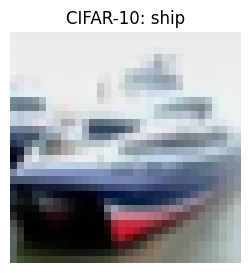

In [6]:
image_tensor, label = test_dataset[SAMPLE_INDEX]
raw_image, raw_label = raw_test_dataset[SAMPLE_INDEX]

print("Indeks obrazu:", SAMPLE_INDEX)
print("Prawdziwa klasa:", classes[label])

plt.figure(figsize=(3, 3))
plt.imshow(raw_image)
plt.title(f"CIFAR-10: {classes[label]}")
plt.axis("off")
plt.show()

## Predykcja modelu dla wybranego obrazu

Sprawdzamy, czy analizowany obraz jest poprawnie klasyfikowany przez model.

In [7]:
predictions = adom.predict_topk_classes(
    model=model_vgg16,
    image_tensor=image_tensor,
    classes=classes,
    k=5
)

for prediction in predictions:
    print(
        prediction["rank"],
        prediction["class_name"],
        f'{prediction["probability_percent"]:.2f}%'
    )

1 ship 92.33%
2 automobile 6.36%
3 airplane 1.30%
4 truck 0.02%
5 frog 0.00%


## Analiza feature maps

Podajemy obraz do modelu i wizualizujemy mapy cech z wybranych warstw `model.features`.

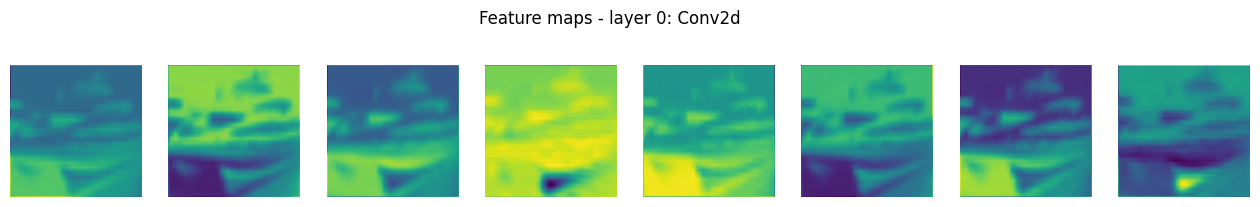

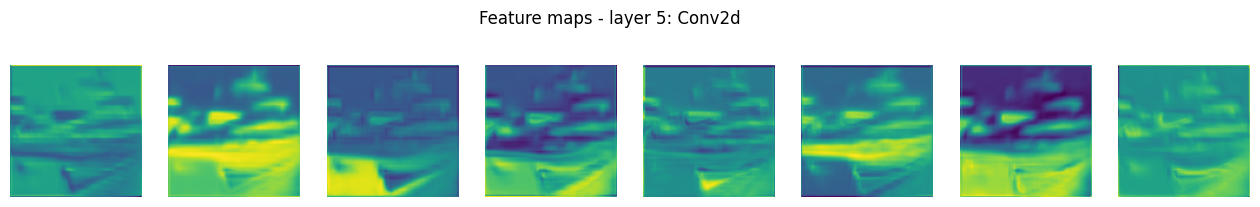

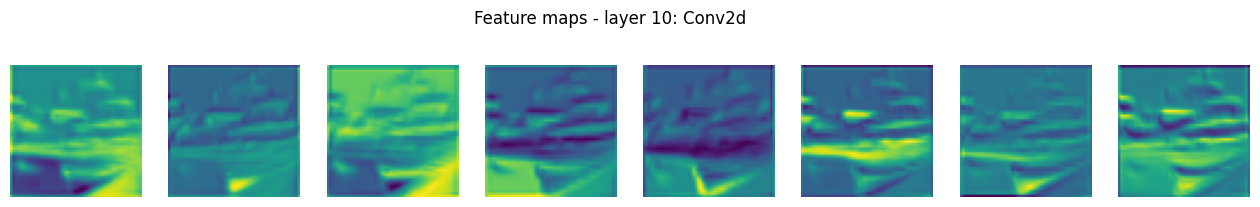

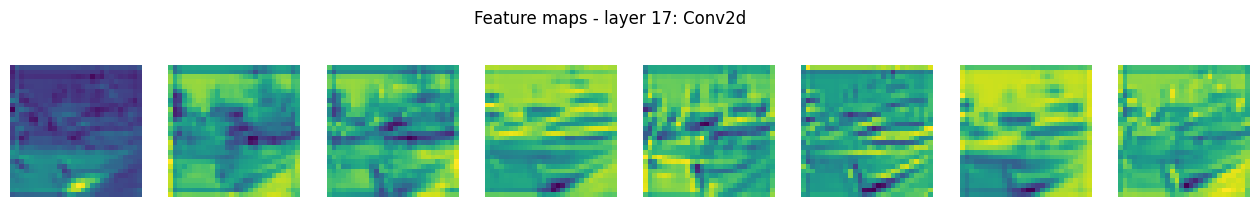

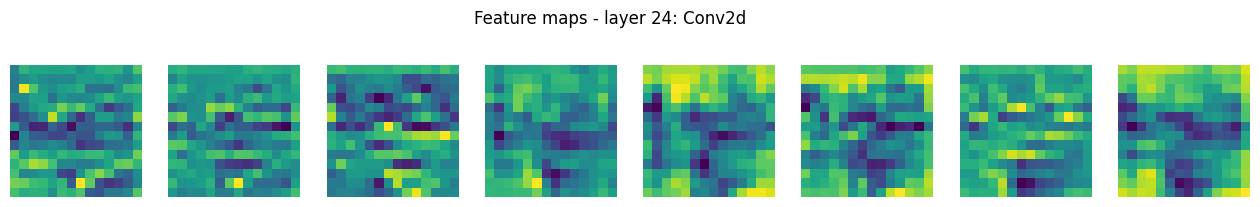

In [8]:
adom.visualize_feature_maps(
    model=model_vgg16,
    image_tensor=image_tensor,
    layer_indices=LAYER_INDICES,
    max_maps=MAX_MAPS
)

## Wnioski

Przeprowadzona analiza feature maps pozwoliła prześledzić, jak zmienia się reprezentacja obrazu w kolejnych warstwach konwolucyjnych VGG16. Analizę przeprowadzono z wykorzystaniem wybranego obrazu ze zbioru testowego CIFAR-10, który został poprawnie sklasyfikowany przez model. Analiza obejmuje kilka wybranych warstw konwolucyjnych sieci.

Na początkowych warstwach można zaobserwować duże powiązanie z oryginalnym obrazem. Mapy cech z tych warstw pokazują głównie proste informacje wizualne, takie jak krawędzie, kontury i podstawowe układy kolorów. Oznacza to, że warstwy te pełnią rolę ekstraktora prostych cech niskiego poziomu.

W kolejnych warstwach możemy zauważyć mniejsze podobieństwo do oryginalnego obrazu. Aktywacje są bardziej selektywne i skupiają się tylko na wybranych fragmentach obrazu. W tych warstwach można zaobserwować bardziej złożone wzory, które mogą odpowiadać fragmentom obiektów lub bardziej abstrakcyjnym cechom.

W jeszcze głębszych warstwach mapy cech stają się coraz bardziej abstrakcyjne i trudniejsze do bezpośredniej interpretacji wizualnej.

Można również zauważyć, że część map cech może mieć silne aktywacje, natomiast inne mogą być prawie jednolite lub słabo pobudzone. Oznacza to, że nie wszystkie kanały danej warstwy są aktywne w takim samym stopniu. Wynika to z tego, że poszczególne filtry w warstwach konwolucyjnych specjalizują się w wykrywaniu różnych cech, które nie zawsze muszą występować w analizowanym obrazie.

Przeprowadzenie takiej analizy pozwala na lepsze zrozumienie działania sieci VGG16, jak i pokazanie, że klasyfikacja nie opiera się bezpośrednio na pojedynczych pikselach, ale na stopniowo budowanych reprezentacjach cech.

Eksperyment potwierdził hierarchiczny charakter reprezentacji tworzonych przez VGG16. Początkowe warstwy wykrywają proste cechy wizualne, środkowe warstwy łączą je w bardziej złożone wzorce, a głębsze warstwy tworzą abstrakcyjne reprezentacje wykorzystywane do klasyfikacji obrazów CIFAR-10.